Zeal College of Engineering and Research  
Subject: LP-V  

Name: Jenil Girish Rathod  
Class: BE  
Div: B  
Batch: B1  
Roll No: B22009  

Group B: Practical No 2:
Classification using Deep neural network (Any One from the following)  
1. Multiclass classification using Deep Neural Networks: Example: Use the OCR letter  recognition dataset https://archive.ics.uci.edu/ml/datasets/letter+recognition 
2. Binary classification using Deep Neural Networks Example: Classify movie reviews into positive" reviews and "negative" reviews, just based on the text content of the reviews. Use IMDB dataset

## Workflow

1. Load the OCR letter recognition dataset
2. Display the dataset with column names
3. Clean and inspect the data
4. Encode labels and scale features
5. Train a PyTorch classifier
6. Report accuracy, precision, recall, F1, and confusion matrix

In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# Load OCR dataset from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/letter-recognition/letter-recognition.data"
column_names = ["letter"] + [f"feature_{i}" for i in range(1, 17)]
data = pd.read_csv(url, header=None, names=column_names)

print("Dataset shape:", data.shape)
print("Unique classes:", sorted(data["letter"].unique()))
print("Missing values:", data.isnull().sum().sum())
print("\nDataset preview with column names:")
print(data.head())

duplicate_count = data.duplicated().sum()
print("\nDuplicate rows:", duplicate_count)
if duplicate_count > 0:
    data = data.drop_duplicates().reset_index(drop=True)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(data["letter"])
x = data.drop(columns=["letter"]).astype(float).values

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

majority_class = np.bincount(y_train).argmax()
baseline_accuracy = np.mean(y_test == majority_class)

print("\nTraining samples:", x_train.shape[0])
print("Test samples:", x_test.shape[0])
print("Features per sample:", x_train.shape[1])
print("Baseline accuracy (majority class):", round(baseline_accuracy, 4))

Dataset shape: (20000, 17)
Unique classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Missing values: 0

Dataset preview with column names:
  letter  feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0      T          2          8          3          5          1          8   
1      I          5         12          3          7          2         10   
2      D          4         11          6          8          6         10   
3      N          7         11          6          6          3          5   
4      G          2          1          3          1          1          8   

   feature_7  feature_8  feature_9  feature_10  feature_11  feature_12  \
0         13          0          6           6          10           8   
1          5          5          4          13           3           9   
2          6          2          6          10           3           7   
3      

In [3]:
class OCRClassifier(nn.Module):
    def __init__(self, input_dim: int, num_classes: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.network(x)


x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(x_train_tensor, y_train_tensor), batch_size=128, shuffle=True)
model = OCRClassifier(x_train.shape[1], len(label_encoder.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
patience = 10
counter = 0
best_state = None

x_train_sub, x_val_sub, y_train_sub, y_val_sub = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
train_loader = DataLoader(
    TensorDataset(torch.tensor(x_train_sub, dtype=torch.float32), torch.tensor(y_train_sub, dtype=torch.long)),
    batch_size=128,
    shuffle=True,
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(x_val_sub, dtype=torch.float32), torch.tensor(y_val_sub, dtype=torch.long)),
    batch_size=128,
    shuffle=False,
)

for epoch in range(1, 51):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_x.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == batch_y).sum().item()
        train_total += batch_x.size(0)

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_x.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == batch_y).sum().item()
            val_total += batch_x.size(0)

    train_loss /= train_total
    val_loss /= val_total
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

if best_state is not None:
    model.load_state_dict(best_state)

print("Best validation accuracy:", round(best_val_acc, 4))

Epoch 1: train_loss=2.6550, train_acc=0.2964, val_loss=1.7410, val_acc=0.5557
Epoch 2: train_loss=1.5507, train_acc=0.5395, val_loss=1.1564, val_acc=0.6866
Epoch 3: train_loss=1.2590, train_acc=0.6159, val_loss=0.9812, val_acc=0.7211
Epoch 4: train_loss=1.1382, train_acc=0.6397, val_loss=0.8849, val_acc=0.7412
Epoch 5: train_loss=1.0491, train_acc=0.6705, val_loss=0.8093, val_acc=0.7623
Epoch 6: train_loss=0.9783, train_acc=0.6897, val_loss=0.7581, val_acc=0.7780
Epoch 7: train_loss=0.9341, train_acc=0.7076, val_loss=0.7032, val_acc=0.7934
Epoch 8: train_loss=0.8871, train_acc=0.7209, val_loss=0.6667, val_acc=0.8052
Epoch 9: train_loss=0.8515, train_acc=0.7275, val_loss=0.6289, val_acc=0.8179
Epoch 10: train_loss=0.8221, train_acc=0.7391, val_loss=0.6001, val_acc=0.8269
Epoch 11: train_loss=0.7906, train_acc=0.7505, val_loss=0.5752, val_acc=0.8299
Epoch 12: train_loss=0.7619, train_acc=0.7537, val_loss=0.5478, val_acc=0.8406
Epoch 13: train_loss=0.7514, train_acc=0.7600, val_loss=0.531

Test accuracy: 0.9172
Precision: 0.92
Recall: 0.9172
F1-score: 0.9176

Classification report:
              precision    recall  f1-score   support

           A       0.99      0.97      0.98       151
           B       0.78      0.93      0.85       146
           C       0.97      0.89      0.93       142
           D       0.94      0.92      0.93       152
           E       0.89      0.84      0.87       145
           F       0.91      0.91      0.91       150
           G       0.83      0.91      0.87       149
           H       0.92      0.83      0.87       141
           I       0.99      0.88      0.93       105
           J       0.94      0.94      0.94       143
           K       0.90      0.94      0.92       144
           L       0.97      0.84      0.90       134
           M       0.99      0.95      0.97       146
           N       0.94      0.91      0.92       138
           O       0.86      0.91      0.88       144
           P       0.95      0.91      0.

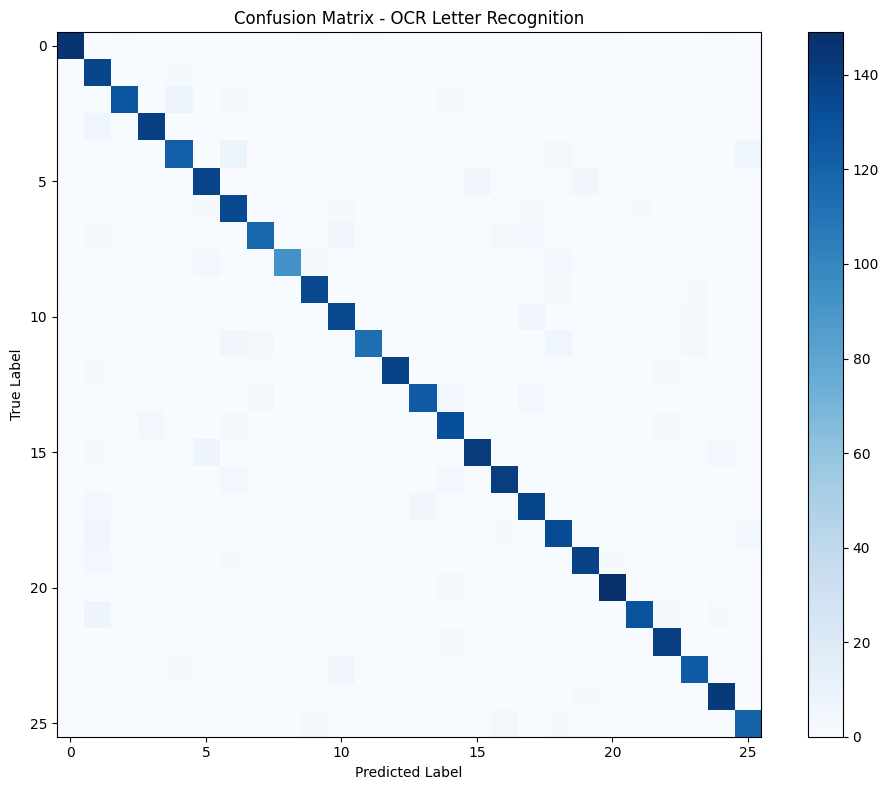

Sample predictions:
Actual: E, Predicted: E
Actual: Y, Predicted: Y
Actual: F, Predicted: F
Actual: E, Predicted: L
Actual: D, Predicted: D


In [4]:
model.eval()
with torch.no_grad():
    y_prob = torch.softmax(model(x_test_tensor.to(device)), dim=1).cpu().numpy()
    y_pred = np.argmax(y_prob, axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("Test accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))
print("\nComparison (Baseline vs Model):")
print(f"Accuracy: {baseline_accuracy:.4f} -> {accuracy:.4f}")

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - OCR Letter Recognition")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.tight_layout()
plt.show()

sample_indices = np.random.choice(len(x_test), size=5, replace=False)
print("Sample predictions:")
for idx in sample_indices:
    actual = label_encoder.inverse_transform([y_test[idx]])[0]
    predicted = label_encoder.inverse_transform([y_pred[idx]])[0]
    print(f"Actual: {actual}, Predicted: {predicted}")

# Binary Classification Using a PyTorch Neural Network

This notebook classifies IMDB movie reviews as positive or negative using PyTorch and CUDA when available.

## Workflow

1. Load the IMDB dataset
2. Decode and display sample reviews
3. Tokenize and pad review sequences
4. Train a PyTorch text classifier
5. Report accuracy, precision, recall, F1, and confusion matrix

In [5]:
import random
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, TensorDataset


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def tokenize(text: str):
    return re.findall(r"[a-z']+", text.lower())


In [6]:
dataset = load_dataset("imdb")
train_texts = dataset["train"]["text"]
train_labels = np.array(dataset["train"]["label"])
test_texts = dataset["test"]["text"]
test_labels = np.array(dataset["test"]["label"])

print("Training samples:", len(train_texts))
print("Test samples:", len(test_texts))
print("Positive reviews in train set:", int(train_labels.sum()))
print("Negative reviews in train set:", int(len(train_labels) - train_labels.sum()))
print("\nSample review:")
print(train_texts[0][:1000])

counter = Counter()
for text in train_texts:
    counter.update(tokenize(text))

vocab_size = 20000
most_common = counter.most_common(vocab_size - 2)
word_to_idx = {"<PAD>": 0, "<UNK>": 1}
for word, _ in most_common:
    word_to_idx[word] = len(word_to_idx)
idx_to_word = {idx: word for word, idx in word_to_idx.items()}
max_len = 200


def encode_text(text: str):
    tokens = tokenize(text)
    indices = [word_to_idx.get(token, 1) for token in tokens[:max_len]]
    if len(indices) < max_len:
        indices += [0] * (max_len - len(indices))
    return indices


x_train = torch.tensor([encode_text(text) for text in train_texts], dtype=torch.long)
y_train = torch.tensor(train_labels, dtype=torch.float32)
x_test = torch.tensor([encode_text(text) for text in test_texts], dtype=torch.long)
y_test = torch.tensor(test_labels, dtype=torch.float32)

baseline_class = int(round(y_train.mean().item()))
baseline_pred = np.full(len(y_test), baseline_class)
baseline_accuracy = accuracy_score(y_test.numpy(), baseline_pred)

print("\nVocabulary size:", len(word_to_idx))
print("Sequence length:", max_len)
print("Baseline accuracy:", round(baseline_accuracy, 4))

Training samples: 25000
Test samples: 25000
Positive reviews in train set: 12500
Negative reviews in train set: 12500

Sample review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM

In [7]:
train_ds, val_ds = torch.utils.data.random_split(
    TensorDataset(x_train, y_train),
    [int(0.8 * len(x_train)), len(x_train) - int(0.8 * len(x_train))],
    generator=torch.Generator().manual_seed(42),
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2, pin_memory=(device.type == "cuda"))
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=(device.type == "cuda"))
test_loader = DataLoader(TensorDataset(x_test, y_test), batch_size=64, shuffle=False, num_workers=2, pin_memory=(device.type == "cuda"))

class TextCNN(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int = 128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv1 = nn.Conv1d(embed_dim, 128, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128 * (max_len // 2), 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = x.flatten(1)
        x = torch.relu(self.fc1(self.dropout(x)))
        return self.fc2(self.dropout(x)).squeeze(1)


model = TextCNN(len(word_to_idx)).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

best_val_acc = 0.0
best_state = None
patience = 3
counter = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, 8):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item() * batch_x.size(0)
        preds = (torch.sigmoid(logits) >= 0.5).long()
        train_correct += (preds == batch_y.long()).sum().item()
        train_total += batch_x.size(0)

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            val_loss += loss.item() * batch_x.size(0)
            preds = (torch.sigmoid(logits) >= 0.5).long()
            val_correct += (preds == batch_y.long()).sum().item()
            val_total += batch_x.size(0)

    train_loss /= train_total
    val_loss /= val_total
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

if best_state is not None:
    model.load_state_dict(best_state)

print("Best validation accuracy:", round(best_val_acc, 4))

C:\Users\jenil\AppData\Local\Temp\ipykernel_14624\2976778156.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
C:\Users\jenil\AppData\Local\Temp\ipykernel_14624\2976778156.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 1: train_loss=0.6612, train_acc=0.5713, val_loss=0.5070, val_acc=0.7624
Epoch 2: train_loss=0.4106, train_acc=0.8174, val_loss=0.3759, val_acc=0.8346
Epoch 3: train_loss=0.2846, train_acc=0.8829, val_loss=0.3537, val_acc=0.8554
Epoch 4: train_loss=0.2101, train_acc=0.9197, val_loss=0.3542, val_acc=0.8580
Epoch 5: train_loss=0.1552, train_acc=0.9424, val_loss=0.4579, val_acc=0.8394
Epoch 6: train_loss=0.1057, train_acc=0.9630, val_loss=0.4472, val_acc=0.8556
Epoch 7: train_loss=0.0723, train_acc=0.9744, val_loss=0.5858, val_acc=0.8554
Early stopping triggered
Best validation accuracy: 0.858


Test accuracy: 0.846
Precision: 0.8563
Recall: 0.8316
F1-score: 0.8438

Comparison (Baseline vs Model):
Accuracy: 0.5000 -> 0.8460


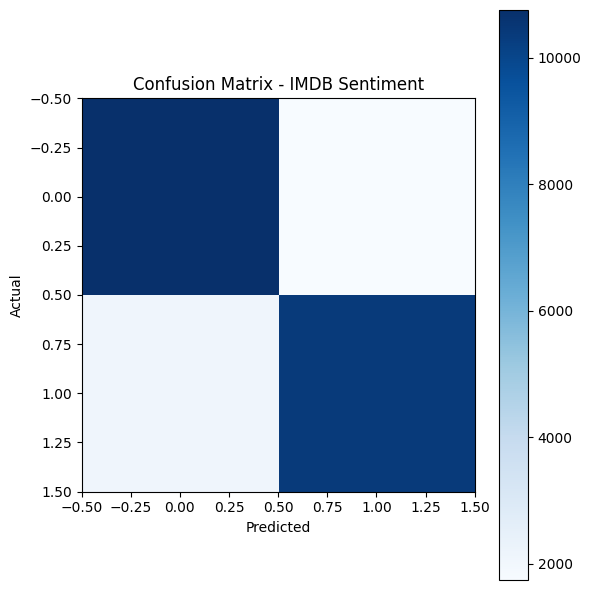

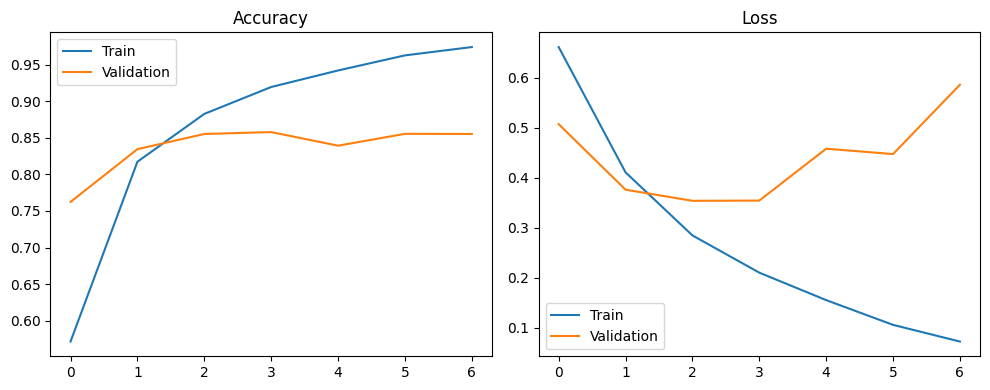

Sample predictions:
Actual: negative, Predicted: negative, Score: 0.0000
Actual: positive, Predicted: negative, Score: 0.1437
Actual: negative, Predicted: negative, Score: 0.0000
Actual: positive, Predicted: positive, Score: 1.0000
Actual: positive, Predicted: positive, Score: 0.9979


In [8]:
model.eval()
all_probs = []
all_preds = []
all_labels = []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        logits = model(batch_x)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(batch_y.numpy().astype(int))

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print("Test accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))
print("\nComparison (Baseline vs Model):")
print(f"Accuracy: {baseline_accuracy:.4f} -> {accuracy:.4f}")

plt.figure(figsize=(6, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - IMDB Sentiment")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()
plt.tight_layout()
plt.show()

sample_indices = np.random.choice(len(x_test), size=5, replace=False)
print("Sample predictions:")
for idx in sample_indices:
    label = "positive" if all_preds[idx] == 1 else "negative"
    truth = "positive" if all_labels[idx] == 1 else "negative"
    print(f"Actual: {truth}, Predicted: {label}, Score: {all_probs[idx]:.4f}")